# RSI-Based Mean Reversion Strategy on BTC and ETH

This notebook implements a 14-day RSI mean reversion strategy for Bitcoin (BTC) and Ethereum (ETH), computes portfolio statistics, and visualizes results.

## 1. Load and Clean Data

In this section, we import libraries, load both datasets, parse dates, sort records, forward-fill close prices, ensure `Log_Return` is present, and drop invalid rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [3]:
def load_and_clean_data(file_path):
    """Load crypto data, clean missing values, and ensure log returns exist."""
    df = pd.read_csv(file_path)

    if "Date" not in df.columns:
        raise ValueError(f"Missing 'Date' column in {file_path}")

    # Parse date, set index, and sort chronologically.
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.set_index("Date").sort_index()


    # Ensure log return column exists and fill missing values if needed.
    computed_log_return = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    if "Log_Return" not in df.columns:
        df["Log_Return"] = computed_log_return
    else:
        df["Log_Return"] = df["Log_Return"].fillna(computed_log_return)

    # Remove rows that still contain NaN values.
    df = df.dropna()
    return df


btc_df = load_and_clean_data("BTC_full_data.csv")
eth_df = load_and_clean_data("ETH_full_data.csv")

print(f"BTC rows: {len(btc_df)} | Date range: {btc_df.index.min().date()} to {btc_df.index.max().date()}")
print(f"ETH rows: {len(eth_df)} | Date range: {eth_df.index.min().date()} to {eth_df.index.max().date()}")

btc_df.head()

BTC rows: 2920 | Date range: 2018-01-02 to 2025-12-30
ETH rows: 2920 | Date range: 2018-01-02 to 2025-12-30


,Open,High,Low,Close,Adj Close,Volume,Log_Return
Date,,,,,,,
2018-01-02,"13,625.000000","15,444.599609","13,163.599609","14,982.099609","14,982.099609",16846600192,0.092589
2018-01-03,"14,978.200195","15,572.799805","14,844.500000","15,201.000000","15,201.000000",16871900160,0.014505
2018-01-04,"15,270.700195","15,739.700195","14,522.200195","15,599.200195","15,599.200195",21783199744,0.025858
2018-01-05,"15,477.200195","17,705.199219","15,202.799805","17,429.500000","17,429.500000",23840899072,0.110945
2018-01-06,"17,462.099609","17,712.400391","16,764.599609","17,527.000000","17,527.000000",18314600448,0.005578


## 2. Feature Engineering (RSI Strategy)

We build a 14-day RSI indicator and generate mean reversion signals:

- `RSI < 30`: Buy (`+1`)
- `RSI > 70`: Sell (`-1`)
- Otherwise: Flat (`0`)

To avoid lookahead bias, positions use `signal.shift(1)`. Strategy returns are computed as `position * Log_Return`.

In [8]:
def apply_rsi_mean_reversion(df, window=14, lower=30, upper=70):

    data = df.copy()

    # RSI components.
    data["delta"] = data["Close"].diff()
    data["gain"] = data["delta"].clip(lower=0)
    data["loss"] = -data["delta"].clip(upper=0)

    data["avg_gain"] = data["gain"].rolling(window=window, min_periods=window).mean()
    data["avg_loss"] = data["loss"].rolling(window=window, min_periods=window).mean()

    # FIX: avoid NaN explosion from division
    rs = data["avg_gain"] / (data["avg_loss"] + 1e-10)
    data["RSI"] = 100 - (100 / (1 + rs))

    # Trading signal
    data["signal"] = np.select(
        [data["RSI"] < lower, data["RSI"] > upper],
        [1, -1],
        default=0,
    )

    # Position (no lookahead bias)
    data["position"] = data["signal"].shift(1).fillna(0)

    # Strategy returns
    data["strategy_return"] = data["position"] * data["Log_Return"]
    data["cumulative_pnl"] = data["strategy_return"].cumsum()

    return data


btc_strategy = apply_rsi_mean_reversion(btc_df)
eth_strategy = apply_rsi_mean_reversion(eth_df)

btc_strategy[["Close", "RSI", "signal", "position", "strategy_return", "cumulative_pnl"]].tail()

,Close,RSI,signal,position,strategy_return,cumulative_pnl
Date,,,,,,
2025-12-26,"87,301.429688",38.331084,0,0.000000,0.000000,-2.175231
2025-12-27,"87,802.156250",40.539193,0,0.000000,0.000000,-2.175231
2025-12-28,"87,835.835938",48.472022,0,0.000000,0.000000,-2.175231
2025-12-29,"87,138.140625",53.575122,0,0.000000,-0.000000,-2.175231
2025-12-30,"88,430.132812",52.956037,0,0.000000,0.000000,-2.175231


## 3. Metrics Calculation

For both BTC and ETH, we compute:

1. Cumulative PnL
2. Average Daily PnL
3. Max Drawdown
4. Annualised Return (365 days)
5. Annualised Volatility
6. Sharpe Ratio (risk-free rate = 3%)
7. Daily Volatility

In [9]:
def calculate_metrics(strategy_df, trading_days=365, risk_free_rate=0.03):
    returns = strategy_df["strategy_return"].dropna()

    cumulative_curve = returns.cumsum()
    running_max = cumulative_curve.cummax()
    drawdown = cumulative_curve - running_max

    avg_daily_pnl = returns.mean()
    daily_volatility = returns.std()

    annualised_return = avg_daily_pnl * trading_days
    annualised_volatility = daily_volatility * np.sqrt(trading_days)

    sharpe_ratio = np.nan
    if annualised_volatility > 1e-10:
        sharpe_ratio = (annualised_return - risk_free_rate) / annualised_volatility

    return {
        "Cumulative PnL": cumulative_curve.iloc[-1],
        "Average Daily PnL": avg_daily_pnl,
        "Annualised Return": annualised_return,
        "Max Drawdown": drawdown.min(),
        "Daily Volatility": daily_volatility,
        "Annual Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
    }

btc_metrics = calculate_metrics(btc_strategy)
eth_metrics = calculate_metrics(eth_strategy)

btc_metrics, eth_metrics

({'Cumulative PnL': np.float64(-2.1752314497540186),
  'Average Daily PnL': np.float64(-0.0007449422773130203),
  'Annualised Return': np.float64(-0.2719039312192524),
  'Max Drawdown': np.float64(-2.6901190440636826),
  'Daily Volatility': np.float64(0.021793750473825254),
  'Annual Volatility': np.float64(0.4163690181751109),
  'Sharpe Ratio': np.float64(-0.725087405740361)},
 {'Cumulative PnL': np.float64(-1.267078013006954),
  'Average Daily PnL': np.float64(-0.0004339308263722442),
  'Annualised Return': np.float64(-0.15838475162586912),
  'Max Drawdown': np.float64(-1.6221593011788777),
  'Daily Volatility': np.float64(0.024468348246472104),
  'Annual Volatility': np.float64(0.46746713687422087),
  'Sharpe Ratio': np.float64(-0.40299036395483967)})

## 4. Output Results

The table below summarizes strategy performance for BTC and ETH.

In [10]:
summary_table = pd.DataFrame({"BTC": btc_metrics, "ETH": eth_metrics})

metric_order = [
    "Cumulative PnL",
    "Average Daily PnL",
    "Annualised Return",
    "Max Drawdown",
    "Daily Volatility",
    "Annual Volatility",
    "Sharpe Ratio",
]

summary_table = summary_table.reindex(metric_order)
summary_table

,BTC,ETH
Cumulative PnL,-2.175231,-1.267078
Average Daily PnL,-0.000745,-0.000434
Annualised Return,-0.271904,-0.158385
Max Drawdown,-2.690119,-1.622159
Daily Volatility,0.021794,0.024468
Annual Volatility,0.416369,0.467467
Sharpe Ratio,-0.725087,-0.402990


## 5. Visualization

We plot:

1. Price and RSI indicator (subplot) for each asset.
2. Cumulative strategy PnL comparison for BTC and ETH.

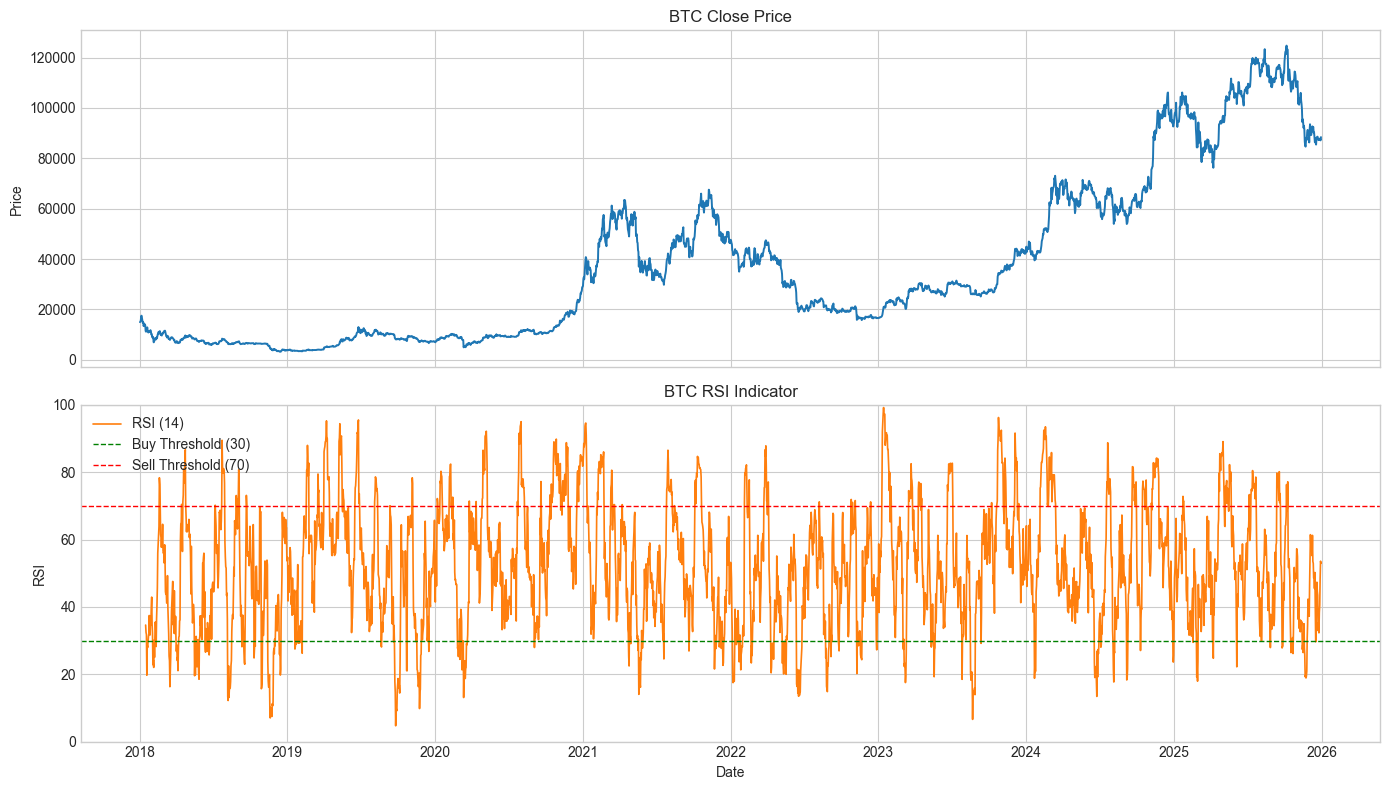

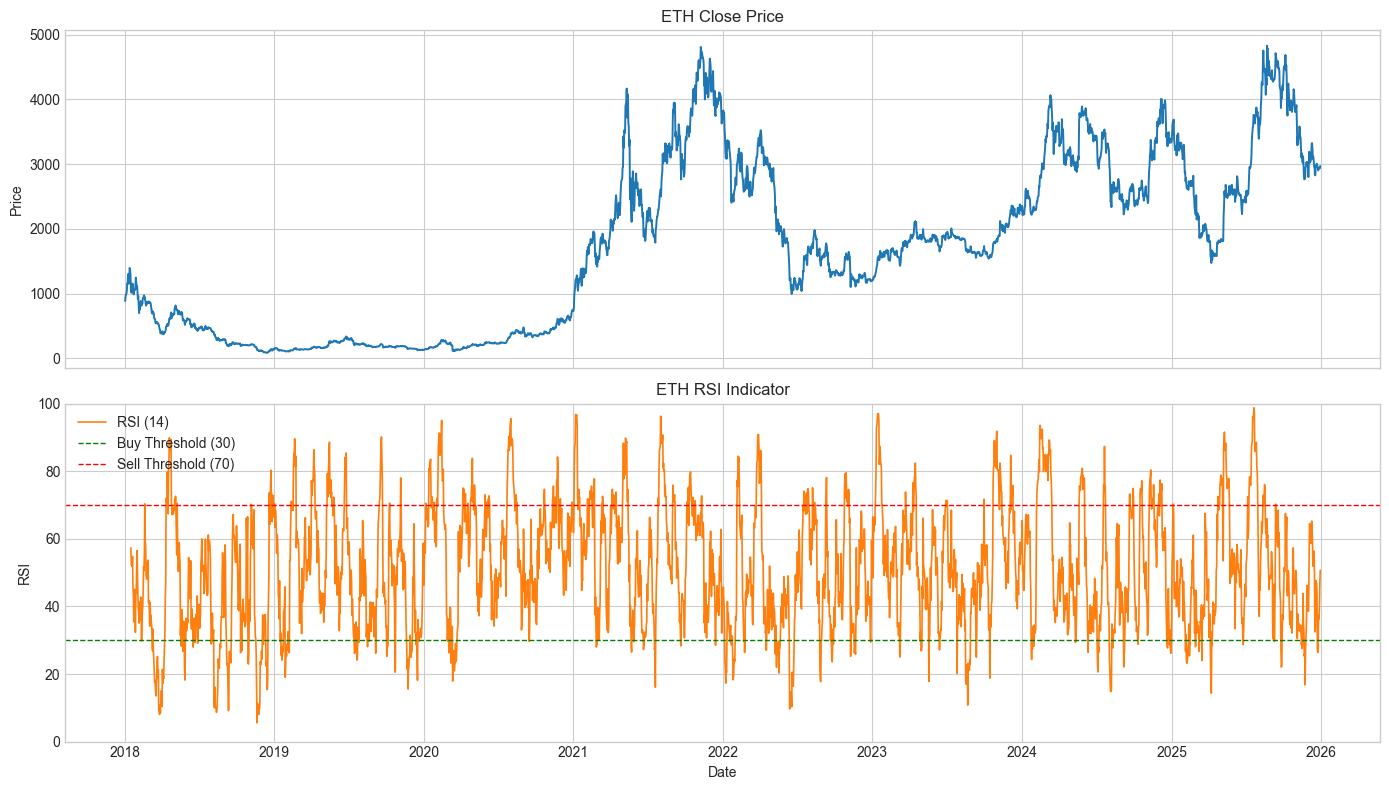

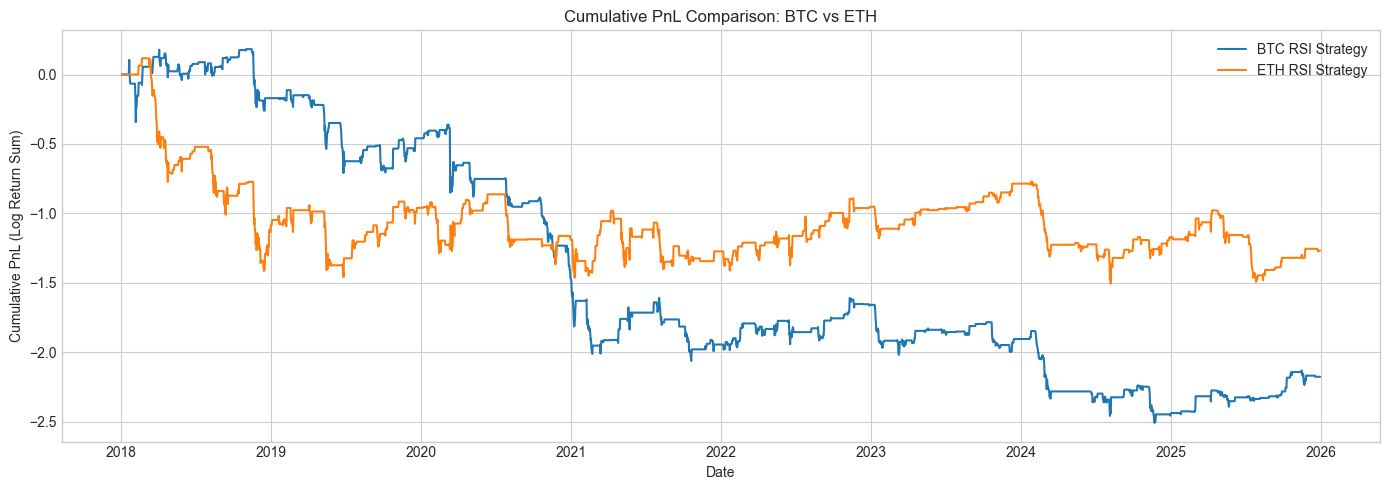

In [7]:
def plot_price_and_rsi(strategy_df, asset_name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top panel: close price.
    axes[0].plot(strategy_df.index, strategy_df["Close"], color="tab:blue", linewidth=1.4)
    axes[0].set_title(f"{asset_name} Close Price")
    axes[0].set_ylabel("Price")

    # Bottom panel: RSI with threshold bands.
    axes[1].plot(strategy_df.index, strategy_df["RSI"], color="tab:orange", linewidth=1.2, label="RSI (14)")
    axes[1].axhline(30, color="green", linestyle="--", linewidth=1, label="Buy Threshold (30)")
    axes[1].axhline(70, color="red", linestyle="--", linewidth=1, label="Sell Threshold (70)")
    axes[1].set_title(f"{asset_name} RSI Indicator")
    axes[1].set_ylabel("RSI")
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc="upper left")

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()


plot_price_and_rsi(btc_strategy, "BTC")
plot_price_and_rsi(eth_strategy, "ETH")

plt.figure(figsize=(14, 5))
plt.plot(btc_strategy.index, btc_strategy["cumulative_pnl"], label="BTC RSI Strategy", linewidth=1.5)
plt.plot(eth_strategy.index, eth_strategy["cumulative_pnl"], label="ETH RSI Strategy", linewidth=1.5)
plt.title("Cumulative PnL Comparison: BTC vs ETH")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL (Log Return Sum)")
plt.legend()
plt.tight_layout()
plt.show()

# Parameters Tuning 

We try some other parameters combination to attain a better result

In [ ]:
# Define parameter combinations
param_list = [
    (14, 30, 70),
    (14, 20, 80),
    (21, 30, 70),
]

results = []

for window, lower, upper in param_list:

    # BTC
    btc_strat = apply_rsi_mean_reversion(btc_df, window, lower, upper)
    btc_metrics = calculate_metrics(btc_strat)

    # ETH
    eth_strat = apply_rsi_mean_reversion(eth_df, window, lower, upper)
    eth_metrics = calculate_metrics(eth_strat)

    # Store results
    results.append({
        "Window": window,
        "Lower": lower,
        "Upper": upper,

        "BTC Sharpe": btc_metrics["Sharpe Ratio"],
        "BTC Return": btc_metrics["Annualised Return"],
        "BTC MDD": btc_metrics["Max Drawdown"],

        "ETH Sharpe": eth_metrics["Sharpe Ratio"],
        "ETH Return": eth_metrics["Annualised Return"],
        "ETH MDD": eth_metrics["Max Drawdown"],
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by BTC Sharpe 
results_df = results_df.sort_values(by="BTC Sharpe", ascending=False)

results_df

,Window,Lower,Upper,BTC Sharpe,BTC Return,BTC MDD,ETH Sharpe,ETH Return,ETH MDD
1,14,20,80,-0.525966,-0.095362,-1.233961,-0.610492,-0.155837,-1.320532
0,14,30,70,-0.725087,-0.271904,-2.690119,-0.402990,-0.158385,-1.622159
2,21,30,70,-0.735419,-0.239911,-2.226732,-0.681343,-0.256852,-2.383310


Although all three combinations perform badly, but the (14, 20, 80) is better in terms of BTC Sharpe, BTC Return, BTC MDD, ETH Return and ETH MDD


# Conclusion


In [13]:
btc_strategy_final = apply_rsi_mean_reversion(btc_df,window=14, lower=20, upper=80)
eth_strategy_final = apply_rsi_mean_reversion(eth_df,window=14, lower=20, upper=80)
btc_metrics_final = calculate_metrics(btc_strategy_final)
eth_metrics_final = calculate_metrics(eth_strategy_final)

In [14]:
summary_table_final = pd.DataFrame({"BTC": btc_metrics_final, "ETH": eth_metrics_final})

metric_order = [
    "Cumulative PnL",
    "Average Daily PnL",
    "Annualised Return",
    "Max Drawdown",
    "Daily Volatility",
    "Annual Volatility",
    "Sharpe Ratio",
]

summary_table_final = summary_table_final.reindex(metric_order)
summary_table_final

,BTC,ETH
Cumulative PnL,-0.762898,-1.246693
Average Daily PnL,-0.000261,-0.000427
Annualised Return,-0.095362,-0.155837
Max Drawdown,-1.233961,-1.320532
Daily Volatility,0.012476,0.015933
Annual Volatility,0.238346,0.304405
Sharpe Ratio,-0.525966,-0.610492
